# Copied from this [notebook](/home/links/ct715/eddy_feedback/reproduce/saffin_2024/saffin.ipynb)

In [13]:
import xarray as xr 
import matplotlib.pyplot as plt
import numpy as np
import os

import functions.eddy_feedback as ef 
import functions.data_wrangling as dw

In [14]:
path = '/home/links/ct715/data_storage/reanalysis/jra55_daily/processed_efp'
data_6h = os.path.join(path, 'k123_6h_ubar_epf-pr-QG_1MS_1958-2016.nc')

# import dataset for maths servers
ds_6h = xr.open_dataset(data_6h)
ds_6h


<xarray.Dataset> Size: 5GB
Dimensions:      (time: 708, level: 37, lat: 73, lon: 144)
Coordinates:
  * lon          (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lat          (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 85.0 87.5 90.0
  * level        (level) float64 296B 1e+03 975.0 950.0 925.0 ... 3.0 2.0 1.0
    year         (time) int64 6kB ...
  * time         (time) datetime64[ns] 6kB 1958-01-31 1958-02-28 ... 2016-12-31
Data variables: (12/17)
    u            (time, level, lat, lon) float32 1GB ...
    v            (time, level, lat, lon) float32 1GB ...
    t            (time, level, lat, lon) float32 1GB ...
    omega        (time, level, lat, lon) float32 1GB ...
    ubar         (time, level, lat) float32 8MB ...
    ep1_QG       (time, level, lat) float64 15MB ...
    ...           ...
    div1_QG_123  (time, level, lat) float64 15MB ...
    div2_QG_123  (time, level, lat) float64 15MB ...
    ep1_QG_gt3   (time, level, lat) float64 15MB ...
    ep2_QG_gt3   (time, level, lat) float64 15MB ...
    div1_QG_gt3  (time, level, lat) float64 15MB ...
    div2_QG_gt3  (time, level, lat) float64 15MB ...

In [15]:
djf = dw.seasonal_mean(ds_6h, season='djf')
jas = dw.seasonal_mean(ds_6h, season='jas')

Cutting incomplete seasons from dataset...
Cutting incomplete seasons from dataset...


In [19]:
jas

<xarray.Dataset> Size: 383MB
Dimensions:      (time: 59, level: 37, lat: 73, lon: 144)
Coordinates:
  * lon          (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lat          (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 85.0 87.5 90.0
  * level        (level) float64 296B 1e+03 975.0 950.0 925.0 ... 3.0 2.0 1.0
  * time         (time) int64 472B 1958 1959 1960 1961 ... 2013 2014 2015 2016
Data variables: (12/17)
    u            (time, level, lat, lon) float32 92MB -3.027 -2.824 ... -0.532
    v            (time, level, lat, lon) float32 92MB -4.593 -4.721 ... -0.6709
    t            (time, level, lat, lon) float32 92MB 234.1 234.1 ... 268.8
    omega        (time, level, lat, lon) float32 92MB -0.02316 ... 3.31e-05
    ubar         (time, level, lat) float32 637kB -8.118e-06 ... -2.035e-05
    ep1_QG       (time, level, lat) float64 1MB 0.0001184 4.861 ... 0.0008158
    ...           ...
    div1_QG_123  (time, level, lat) float64 1MB 5.245e+10 2.753 ... -3.608e+11
    div2_QG_123  (time, level, lat) float64 1MB 0.0 1.638 ... -0.09138 0.0
    ep1_QG_gt3   (time, level, lat) float64 1MB -1.048e-07 -0.3772 ... 7.285e-07
    ep2_QG_gt3   (time, level, lat) float64 1MB 0.0 -0.0002072 ... -5.457e-28
    div1_QG_gt3  (time, level, lat) float64 1MB -4.64e+07 -0.7456 ... -3.224e+08
    div2_QG_gt3  (time, level, lat) float64 1MB -1.656e-21 ... -9.047e-23

### Zonal-mean zonal wind

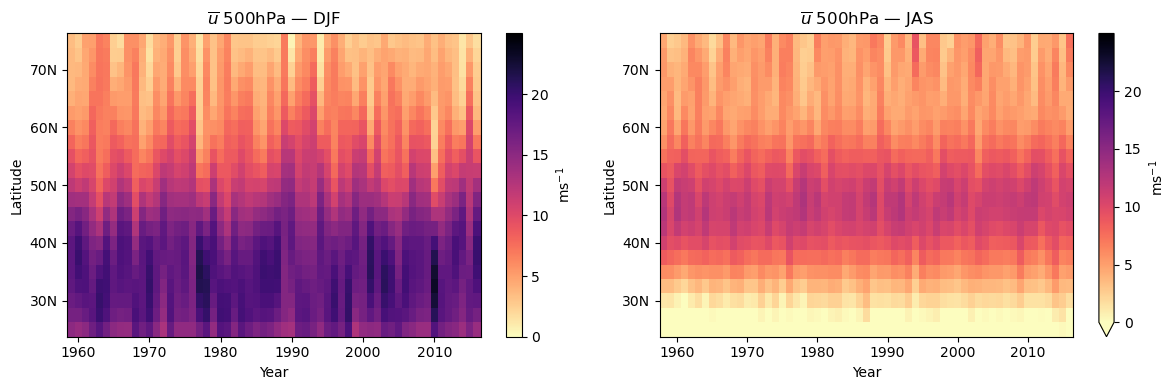

In [ ]:
seasons = {'DJF': djf, 'JAS': jas}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (season_name, ds) in zip(axes, seasons.items()):
    u = ds.ubar.sel(level=500.)
    u = u.where(ds.lat >= 25., drop=True)
    u = u.where(ds.lat <= 75., drop=True)
    u = u.transpose()

    u.plot(ax=ax, cmap='magma_r', vmin=0, vmax=25,
           cbar_kwargs={'label': 'ms$^{-1}$', 'ticks': [0, 5, 10, 15, 20]})
    ax.set_yticks(np.arange(30, 80, 10))
    ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
    ax.set_title(f'$\\overline{{u}}$ 500hPa — {season_name}')
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

### DivFy (QG)

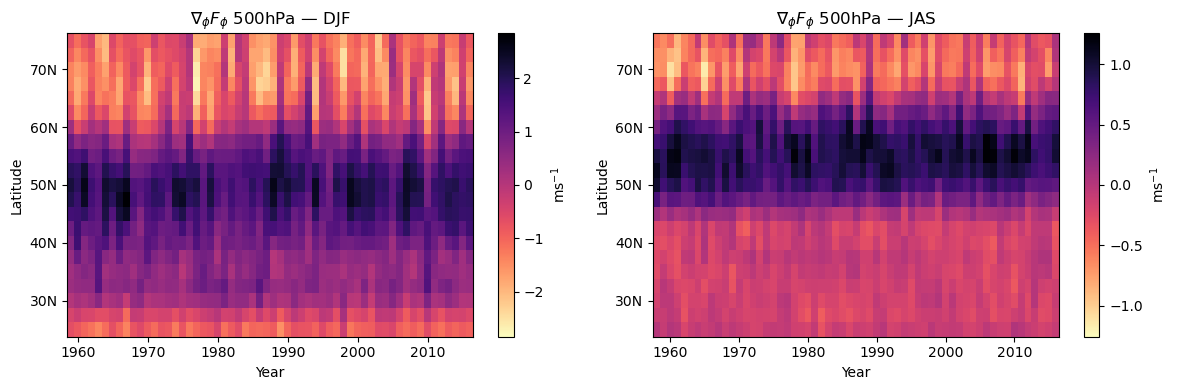

In [22]:
seasons = {'DJF': djf, 'JAS': jas}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (season_name, ds) in zip(axes, seasons.items()):
    div1_QG = ds.div1_QG.sel(level=500.)
    div1_QG = div1_QG.where(ds.lat >= 25., drop=True)
    div1_QG = div1_QG.where(ds.lat <= 75., drop=True)
    div1_QG = div1_QG.transpose()

    div1_QG.plot(ax=ax, cmap='magma_r',
           cbar_kwargs={'label': 'ms$^{-1}$'})
    ax.set_yticks(np.arange(30, 80, 10))
    ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
    ax.set_title(f'$\\nabla_\\phi F_\\phi$ 500hPa — {season_name}')
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

### DivFy (QG_123)

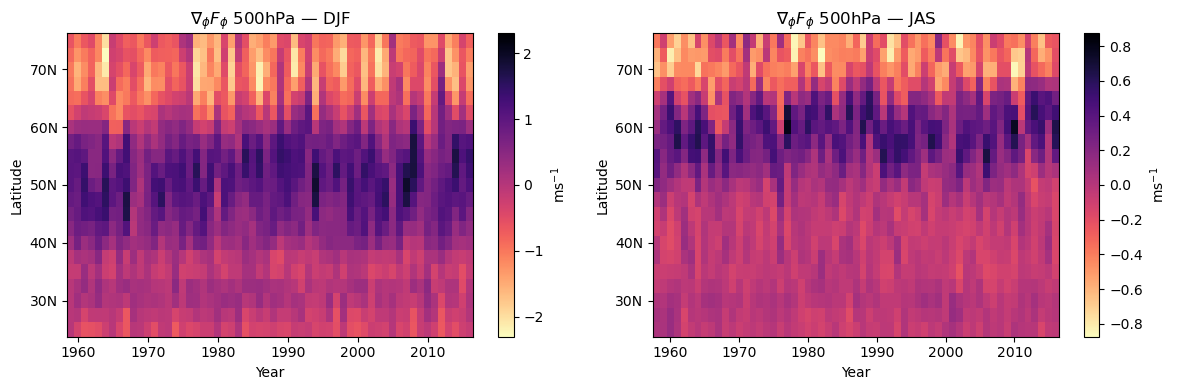

In [23]:
seasons = {'DJF': djf, 'JAS': jas}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (season_name, ds) in zip(axes, seasons.items()):
    div1_QG_123 = ds.div1_QG_123.sel(level=500.)
    div1_QG_123 = div1_QG_123.where(ds.lat >= 25., drop=True)
    div1_QG_123 = div1_QG_123.where(ds.lat <= 75., drop=True)
    div1_QG_123 = div1_QG_123.transpose()

    div1_QG_123.plot(ax=ax, cmap='magma_r',
           cbar_kwargs={'label': 'ms$^{-1}$'})
    ax.set_yticks(np.arange(30, 80, 10))
    ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
    ax.set_title(f'$\\nabla_\\phi F_\\phi$ 500hPa — {season_name}')
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

### DivFy (QG_gt3)

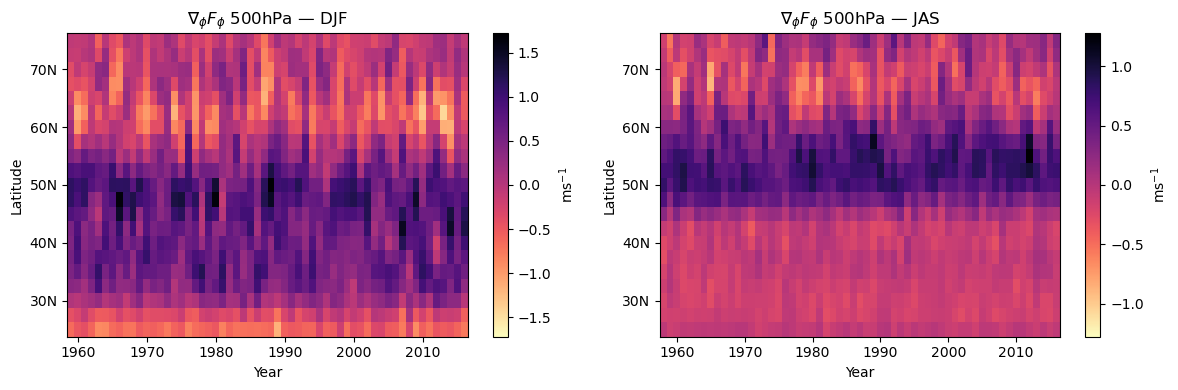

In [24]:
seasons = {'DJF': djf, 'JAS': jas}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (season_name, ds) in zip(axes, seasons.items()):
    div1_QG_gt3 = ds.div1_QG_gt3.sel(level=500.)
    div1_QG_gt3 = div1_QG_gt3.where(ds.lat >= 25., drop=True)
    div1_QG_gt3 = div1_QG_gt3.where(ds.lat <= 75., drop=True)
    div1_QG_gt3 = div1_QG_gt3.transpose()

    div1_QG_gt3.plot(ax=ax, cmap='magma_r',
           cbar_kwargs={'label': 'ms$^{-1}$'})
    ax.set_yticks(np.arange(30, 80, 10))
    ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
    ax.set_title(f'$\\nabla_\\phi F_\\phi$ 500hPa — {season_name}')
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

# Plot both variables

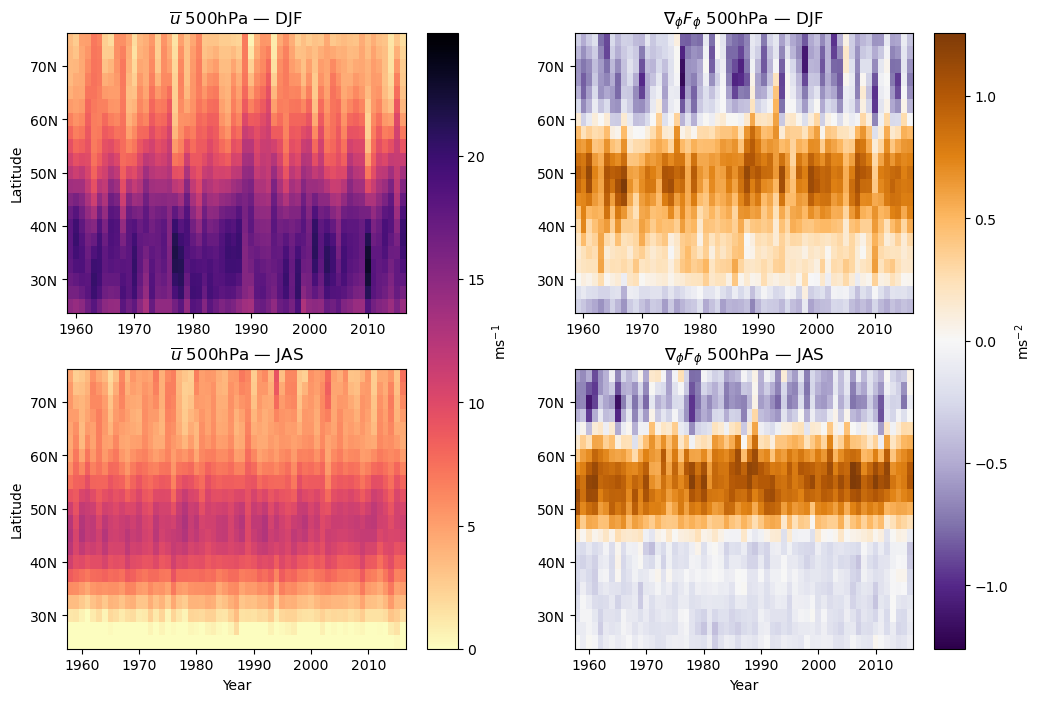

In [27]:
seasons = {'DJF': djf, 'JAS': jas}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    # --- LHS: u ---
    u = ds.ubar.sel(level=500.)
    u = u.where(ds.lat >= 25., drop=True).where(ds.lat <= 75., drop=True)
    u = u.transpose()

    im_u = u.plot(ax=axes[row, 0], cmap='magma_r', vmin=0, vmax=25,
                  add_colorbar=False)
    axes[row, 0].set_yticks(np.arange(30, 80, 10))
    axes[row, 0].set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
    axes[row, 0].set_title(f'$\\overline{{u}}$ 500hPa — {season_name}')
    axes[row, 0].set_ylabel('Latitude')
    axes[row, 0].set_xlabel('Year')

    # --- RHS: div1 ---
    div1 = ds.div1_QG.sel(level=500.)
    div1 = div1.where(ds.lat >= 25., drop=True).where(ds.lat <= 75., drop=True)
    div1 = div1.transpose()

    im_div1 = div1.plot(ax=axes[row, 1], cmap='PuOr_r',
                        add_colorbar=False)
    axes[row, 1].set_yticks(np.arange(30, 80, 10))
    axes[row, 1].set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
    axes[row, 1].set_title(f'$\\nabla_\\phi F_\\phi$ 500hPa — {season_name}')
    axes[row, 1].set_ylabel('')
    axes[row, 1].set_xlabel('Year')

for ax in axes[0, :]:
    ax.set_xlabel('')

fig.colorbar(im_u,    ax=axes[:, 0], label='ms$^{-1}$', ticks=[0, 5, 10, 15, 20])
fig.colorbar(im_div1, ax=axes[:, 1], label='ms$^{-2}$')
plt.show()

# Covariance

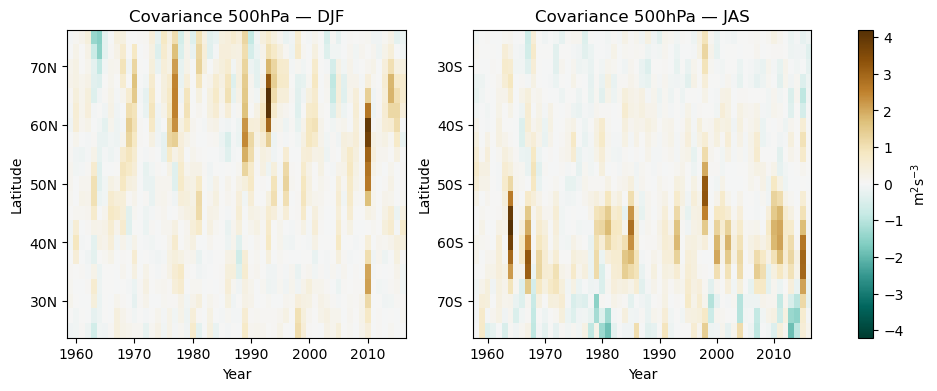

In [31]:
panels = {
    'DJF': {'ds': djf, 'lat_min': 25.,  'lat_max': 75.,
            'ticks': np.arange(30, 80, 10),
            'ticklabels': ['30N', '40N', '50N', '60N', '70N']},
    'JAS': {'ds': jas, 'lat_min': -75., 'lat_max': -25.,
            'ticks': np.arange(-70, -20, 10),
            'ticklabels': ['70S', '60S', '50S', '40S', '30S']},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (season_name, p) in zip(axes, panels.items()):
    ds = p['ds']

    u    = ds.ubar.sel(level=500.)
    div1 = ds.div1_QG.sel(level=500.)

    u    = u.where(ds.lat >= p['lat_min'], drop=True).where(ds.lat <= p['lat_max'], drop=True)
    div1 = div1.where(ds.lat >= p['lat_min'], drop=True).where(ds.lat <= p['lat_max'], drop=True)

    uanom    = u - u.mean('time')
    div1anom = div1 - div1.mean('time')
    prod = (uanom * div1anom).transpose()

    im = prod.plot(ax=ax, cmap='BrBG_r', add_colorbar=False)
    ax.set_yticks(p['ticks'])
    ax.set_yticklabels(p['ticklabels'])
    ax.set_title(f'Covariance 500hPa — {season_name}')
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Year')

fig.colorbar(im, ax=axes, label='m$^2$s$^{-3}$')
plt.show()

# Correlation

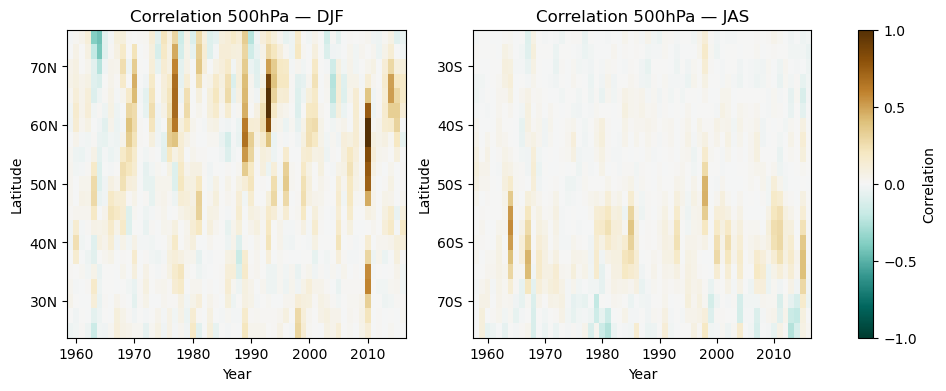

In [33]:
panels = {
    'DJF': {'ds': djf, 'lat_min': 25.,  'lat_max': 75.,
            'ticks': np.arange(30, 80, 10),
            'ticklabels': ['30N', '40N', '50N', '60N', '70N']},
    'JAS': {'ds': jas, 'lat_min': -75., 'lat_max': -25.,
            'ticks': np.arange(-70, -20, 10),
            'ticklabels': ['70S', '60S', '50S', '40S', '30S']},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (season_name, p) in zip(axes, panels.items()):
    ds = p['ds']

    u    = ds.ubar.sel(level=500.)
    div1 = ds.div1_QG.sel(level=500.)

    u    = u.where(ds.lat >= p['lat_min'], drop=True).where(ds.lat <= p['lat_max'], drop=True)
    div1 = div1.where(ds.lat >= p['lat_min'], drop=True).where(ds.lat <= p['lat_max'], drop=True)

    uanom    = u - u.mean('time')
    div1anom = div1 - div1.mean('time')
    prod = uanom * div1anom

    corr = (prod / (u.std() * div1.std())).transpose()

    im = corr.plot(ax=ax, cmap='BrBG_r', vmin=-1., vmax=1.,
                   add_colorbar=False)
    ax.set_yticks(p['ticks'])
    ax.set_yticklabels(p['ticklabels'])
    ax.set_title(f'Correlation 500hPa — {season_name}')
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Year')

fig.colorbar(im, ax=axes, label='Correlation', ticks=[-1, -0.5, 0, 0.5, 1])
plt.show()

# Plot all figures

(11.023622047244094, 7.086614173228346)


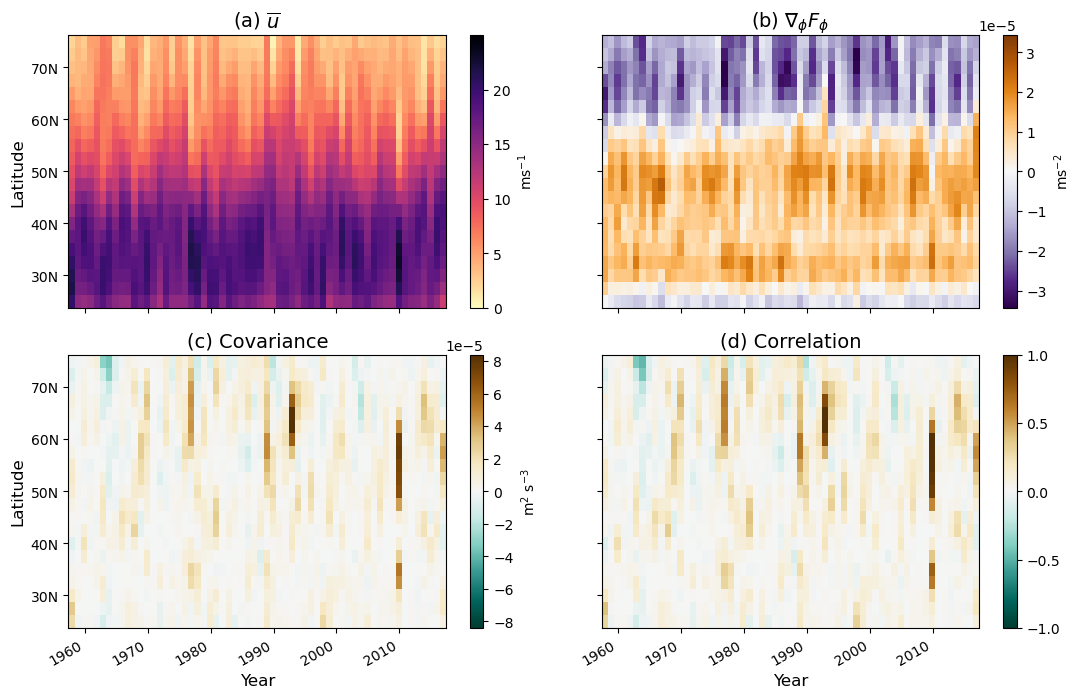

In [ ]:
inches = 1/25.4 

width = 280 #(180/4)*3
height = 180 #(325/4)*3

figsize = (width*inches, height*inches)
print(figsize)

fig, axs = plt.subplots(nrows=2, ncols=2, sharey=True, sharex=True, figsize=figsize)

# plot ubar
u.plot(ax=axs[0,0], cmap='magma_r', vmin=0, vmax=25,
       cbar_kwargs={'label': 'ms$^{-1}$', 'ticks':[0, 5, 10, 15, 20]})
axs[0,0].set_yticks(np.arange(30,80, 10))
axs[0,0].set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
axs[0,0].set_title('(a) $\\overline{u}$', fontsize=14)
axs[0,0].set_ylabel('Latitude', fontsize=12)
axs[0,0].set_xlabel('')


# plot div1
div1.plot(ax=axs[0,1], cmap='PuOr_r',
       cbar_kwargs={'label': 'ms$^{-2}$'})
axs[0,1].set_title('(b) $\\nabla_\\phi F_\\phi$', fontsize=14)
axs[0,1].set_ylabel('')
axs[0,1].set_xlabel('')

# plot covariance
prod.plot(ax=axs[1,0], cmap='BrBG_r', cbar_kwargs={'label': 'm$^2$ s$^{-3}$'})#, 'ticks':[-5e-5,0,5e-5]})
axs[1,0].set_title('(c) Covariance', fontsize=14)
axs[1,0].set_ylabel('Latitude', fontsize=12)
axs[1,0].set_xlabel('Year', fontsize=12)

# plot correlation
corr.plot(ax=axs[1,1], cmap='BrBG_r', vmin=-1., vmax=1.,
          cbar_kwargs={'ticks':[-1,-0.5,0,0.5,1]})
axs[1,1].set_title('(d) Correlation', fontsize=14)
axs[1,1].set_ylabel('')
axs[1,1].set_xlabel('Year', fontsize=12)

# fig.suptitle('Figure 3: Eddy Feedback Parameter at 500hPa', fontsize=16)

plt.tight_layout()
plt.show()

# Daily vs 6-hourly comparison (Not really a difference)

In [12]:
ds_day = xr.open_dataset(data_daily)

ds = {'6h': ds_6h, 'daily': ds_day}

ds_djf, ds_jas = {}, {}
for dataset in ds.keys():
    ds_djf[dataset] = dw.seasonal_mean(ds[dataset], season='djf')
    print(ds_djf[dataset].dims)
    ds_jas[dataset] = dw.seasonal_mean(ds[dataset], season='jas')
    print(ds_jas[dataset].dims)

Cutting incomplete seasons from dataset...
FrozenMappingWarningOnValuesAccess({'time': 58, 'level': 37, 'lat': 73})
Cutting incomplete seasons from dataset...
FrozenMappingWarningOnValuesAccess({'time': 59, 'level': 37, 'lat': 73})
Cutting incomplete seasons from dataset...
FrozenMappingWarningOnValuesAccess({'time': 58, 'level': 37, 'lat': 73})
Cutting incomplete seasons from dataset...
FrozenMappingWarningOnValuesAccess({'time': 59, 'level': 37, 'lat': 73})


### Zonal-mean zonal wind (DJF)

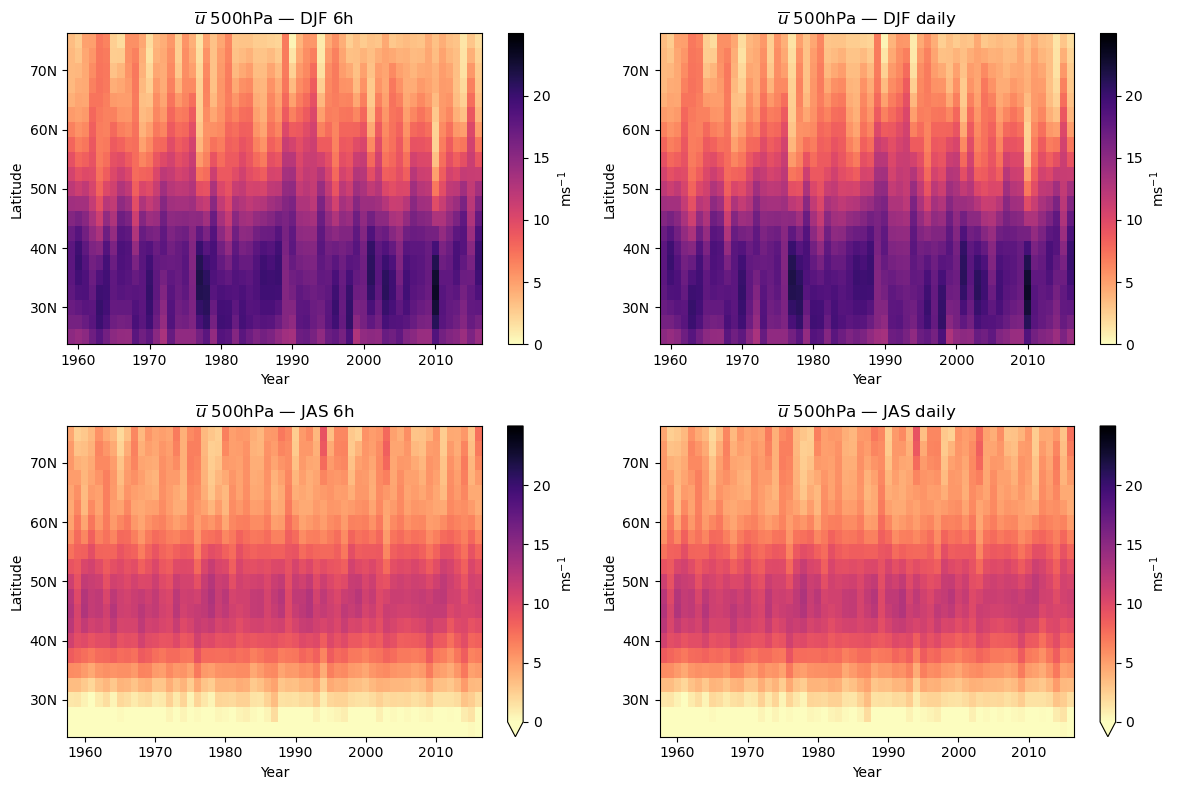

In [13]:
seasons = {'DJF': ds_djf, 'JAS': ds_jas}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (res_name, ds_res) in enumerate(ds.items()):
        ax = axes[row, col]

        u = ds_res.ubar.sel(level=500.)
        u = u.where(ds_res.lat >= 25., drop=True)
        u = u.where(ds_res.lat <= 75., drop=True)
        u = u.transpose()

        u.plot(ax=ax, cmap='magma_r', vmin=0, vmax=25,
               cbar_kwargs={'label': 'ms$^{-1}$', 'ticks': [0, 5, 10, 15, 20]})
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'$\\overline{{u}}$ 500hPa — {season_name} {res_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

### DivFy (primitive)

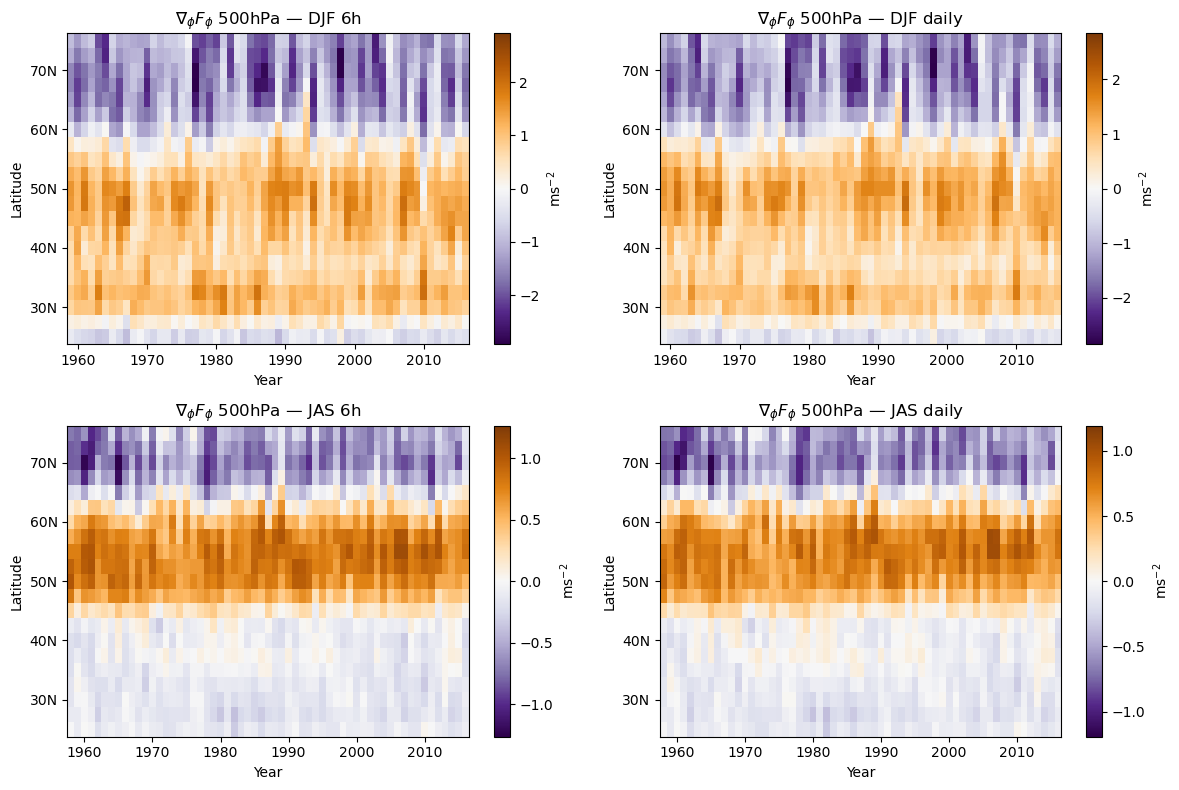

In [14]:
seasons = {'DJF': ds_djf, 'JAS': ds_jas}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (res_name, ds_res) in enumerate(ds.items()):
        ax = axes[row, col]

        div1 = ds_res.div1_pr.sel(level=500.)
        div1 = div1.where(ds_res.lat >= 25., drop=True)
        div1 = div1.where(ds_res.lat <= 75., drop=True)
        div1 = div1.transpose()

        div1.plot(ax=ax, cmap='PuOr_r',# vmin=-3.5e-5, vmax=3.5e-5,
                  cbar_kwargs={'label': 'ms$^{-2}$'})
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'$\\nabla_\\phi F_\\phi$ 500hPa — {season_name} {res_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

### DivFy (QG)

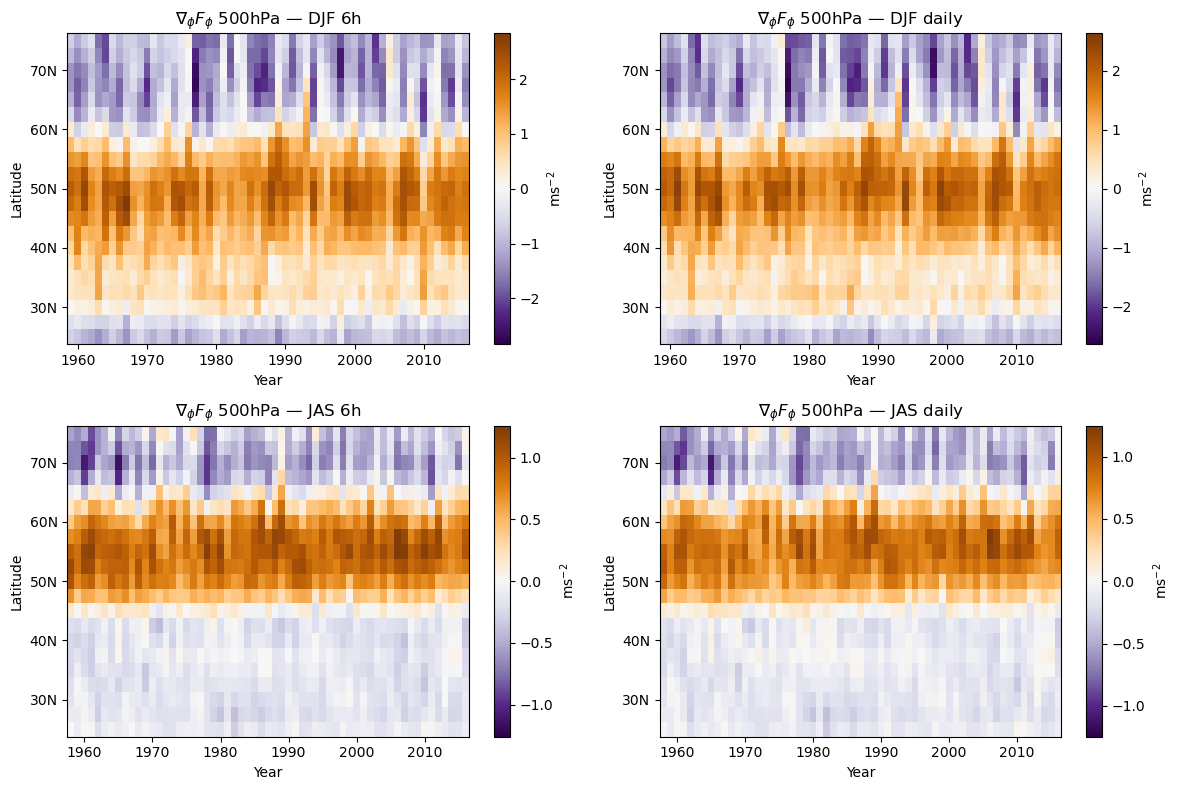

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, (season_name, ds) in enumerate(seasons.items()):
    for col, (res_name, ds_res) in enumerate(ds.items()):
        ax = axes[row, col]

        div1 = ds_res.div1_QG.sel(level=500.)
        div1 = div1.where(ds_res.lat >= 25., drop=True)
        div1 = div1.where(ds_res.lat <= 75., drop=True)
        div1 = div1.transpose()

        div1.plot(ax=ax, cmap='PuOr_r',# vmin=-3.5e-5, vmax=3.5e-5,
                  cbar_kwargs={'label': 'ms$^{-2}$'})
        ax.set_yticks(np.arange(30, 80, 10))
        ax.set_yticklabels(['30N', '40N', '50N', '60N', '70N'])
        ax.set_title(f'$\\nabla_\\phi F_\\phi$ 500hPa — {season_name} {res_name}')
        ax.set_ylabel('Latitude')
        ax.set_xlabel('Year')

plt.tight_layout()
plt.show()